In [1]:
import aeon
from aeon.datasets import load_classification
import numpy as np
from sklearn.metrics import balanced_accuracy_score
import dtw as DTW_package #Name of package is actually dtw-python
from aeon.datasets.dataset_collections import get_available_tsc_datasets
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import random

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Classification functions and divergences

In [2]:
def classify(training_samples, test_data, distance):
    """
    1 nearest neighbours algorithm using the distance or divergence provided. 
    Inputs:
        training_samples: array of labeled data, each row is a signal with label in the first column.
        test_data: array of labeled data, each row is a signal with label in the first column.
        distance: function that computes a dissimilarity or distance between two signals (one dimensional arrays).
    Output: 
        Balanced accuracy of 1nn with selected distance or divergence
    """
    training_samples_labels = training_samples[:, 0]
    test_data_labels = test_data[:, 0]
    train = training_samples[:, 1:]
    test = test_data[:, 1:]
    distances = np.zeros([len(train), len(test)])
    for i in range(len(train)):
        for j in range(len(test)):
            # print(dtw(signal1[j],signal2[i]).distance)
            distances[i, j] = distance(test[j], train[i])

    labels_out = training_samples_labels[np.argmin(distances, axis=0)]
    return balanced_accuracy_score(labels_out, test_data_labels) * 100


def d_T(signal1, signal2, eps=0.001):
    '''
    signal1: dependent variable values of signal 1
    signal2: dependent variable values of signal 2
    eps: regularizing term (See documentation)
    Output: 
        d_T divergence between signal1 and signal2
    '''
    test_grad = np.gradient(signal1)
    test_grad = np.abs(test_grad)
    percentual_eps = eps * np.max(test_grad)
    test_grad += percentual_eps
    test_grad = test_grad/test_grad.sum()

    train_grad = np.gradient(signal2)
    train_grad = np.abs(train_grad)
    percentual_eps = eps * np.max(train_grad)
    train_grad += percentual_eps
    train_grad = train_grad/train_grad.sum()

    g = np.interp(test_grad.cumsum(), train_grad.cumsum(), np.linspace(0, 1, len(signal2)))
    reconst = np.interp(g, np.linspace(0, 1, len(signal2)), signal2)
    return weighted_2_norm(reconst - signal1, np.gradient(g) ** (1 / 2))

def weighted_2_norm(x, w):
    """
        Auciliary function for d_T
    """
    # Ensure x and w are numpy arrays
    x = np.array(x)
    w = np.array(w)

    # Calculate the weighted 2-norm
    norm = np.sqrt(np.sum(w * x ** 2))
    return norm


def dtw(signal1, signal2):
    """
    Inputs: 
        signal1: dependent variable values of signal 1
        signal2: dependent variable values of signal 2
    Output:
        dtw divergence between signal1 and signal2
    """
    return DTW_package.dtw(signal1, signal2).distance

# Synthetic dataset generation

In this section of the notebook we provide functions to create a synthetic dataset of signals. Each class is created using a template $\phi^{(i)}$ and deformations $g\in \mathcal{G}$ that are random non-decreasing functions $g:[0,1] \to [0,1]$. The signals of class $(i)$ are of the form 

$$
    s = \phi^{(i)} \circ g, \text{ with } g\in\mathcal{G}
$$

Examples of how to create a dataset, together with plots of elements of each class are in Section "Classification of synthetic dataset example", which appears below.

In [7]:
def smooth_random_function_with_zeros(num_points=100, seed_points=10, amplitude=1.0, smoothness=2):
    """
    Creates a random smooth function padded with zeros by the following procedure:
        It creates seed_points number of random points with random values and interpolates a polinomial. 
        Cuts the function with a smooth window and padds with zeros.
        Smoothens the whole output with gaussian filter.
        
    Input:
        num_points: part of the domain where a function will be created.
        seed_points: number of random points to interpolate
        amplitude: maximum posible value for random points. 
        smoothness: determines the variance of the gaussian filter. The largest the smoothest.
    Output:
        smooth_function: The output function will be of size 3*num_points. Will have zeros in the first and last num_points points.
    """
    
    # Generate a random points
    random_values = np.random.randn(seed_points) * amplitude

    # Smooth the random points using a Gaussian filter
    interp_fun = np.interp(np.linspace(0, 1, num_points), np.linspace(0, 1, seed_points),random_values)

    # Apply a window function (Hann window) to force it to zero at the boundaries
    window = np.hanning(num_points)
    interp_fun *= window

    # Pads with zeros
    interp_fun = np.concatenate([np.zeros_like(interp_fun ), interp_fun , np.zeros_like(interp_fun )])

    # Smooths by gaussian filtering
    smooth_function = gaussian_filter1d(interp_fun,sigma = smoothness)

    return smooth_function


def smooth_non_decreasing_fun(num_points=100, seed_points=10, amplitude=1.0, smoothness=2, hanning= True):
    """
    Creates a random smooth non-decreasing function to use as a deformation. 
        It creates seed_points number of random points with random positive values and interpolates a polinomial. 
        Cuts the polinomial with a smooth window and padds with zeros.
        Smoothens the polinomial with gaussian filter.
        Integrates the polinomial to create a non-decreasing function. 
        Rescales the output to map [0,1] to [0.3,0.7]. (This is to avoid stretching functions too much so the support stays in [0,1].
        
    Input:
        num_points: part of the domain where a function will be created.
        seed_points: number of random points to interpolate
        amplitude: maximum posible value for random points. 
        smoothness: determines the variance of the gaussian filter. The largest the smoothest.
        hanning: True (rescales the output) 
    Output:
        smooth_function: The output function will be of size 3*num_points. Will have zeros in the first and last num_points points.
    """
    
    # Generate seed_points random positive values to interpolate
    random_values = np.abs(np.random.rand(seed_points))

    # Interpolate, cut the negative values and smooth
    interpolated_values = np.maximum(np.interp(np.linspace(0, 1, 3*num_points), np.linspace(0, 1, seed_points), random_values),0)
    smoothed_function = gaussian_filter1d(interpolated_values,sigma = smoothness)


    if hanning == True:
        # Apply a window function (Hann window )
        window = np.hanning(3*num_points)
        smoothed_function *= window
        density_fun = smoothed_function/smoothed_function.sum()

        b = random.uniform(0,0.33)
        a = random.uniform(0.67,1) - b

        out = a*density_fun.cumsum() + b
    else:
        density_fun = smoothed_function / smoothed_function.sum()
        out = density_fun.cumsum()
    return out

def synthetic_dataset_builder(num_classes= 5,num_samples_per_class = 50, noise_level = 0, create_template = True):
    """
    Creates a synthetic dataset from a template $phi$ and deformations $g$ according to formula $s(t)=phi(g(t))$
    
    Input:
        num_classes
        num_samples_per_class
        create_template: True (automatically creates own templates) - 
                         Otherwise pass an array with num_classes number of rows,
                         where each row represent one template for a class.
    Output: 
        synthetic_dataset: Array of size (num_classes * num_samples_per_class, 601), where the first column of 
                           each row is the class of the row and the clumns [1:] are the signal.
    """
    
    # Example usage
    num_points = 200
    seed_points = 10  # Higher values make it smoother
    amplitude = 2.0  # Adjust the scale for amplitude

    classes = range(0,num_classes)
    samples_per_class = num_samples_per_class*np.ones_like(classes)

    dataset_functions = []
    for class_num in classes:
        template = smooth_random_function_with_zeros(num_points, seed_points, amplitude)
        #plt.plot(template,'r')
        if type(create_template) != bool:
            assert create_template.shape[0] == num_classes, 'Not enough templates provided'
            template = create_template[class_num]
        for num_sample in range(samples_per_class[class_num]):
            random_deformation = smooth_non_decreasing_fun(num_points, seed_points, amplitude)
            sample_fun = np.interp(random_deformation, np.linspace(0, 1, len(template)), template)
            noise = noise_level * np.random.randn(*sample_fun.shape)
            sample_fun += noise
            #plt.plot(sample_fun)
            # Add class at position 0
            sample_fun =  np.insert(sample_fun,0,class_num)
            dataset_functions.append(sample_fun)
        #plt.show()

    synthetic_dataset = np.vstack(dataset_functions)
    return synthetic_dataset


def select_samples(data, num_samples, seed=None):
    '''
    Creates training and test splits with num_samples number of samples per class in the training. The rest remains in test.
    
    Inputs:
        data: labeled data with label on first column.
        num_samples: number of samples per class that are going to be selected for training set.
    Output:
        train and test splits for the dataset.
    '''

    # It will randomly extract num_samples from each class present in data
    if seed!= None:
        random.seed(seed)

    # Check the number of different classes in first column of data
    ul = np.unique(data[:, 0])

    # Separate the data by class
    classes = []
    for i in range(len(ul)):
        classes.append(data[data[:, 0] == ul[i]])
    samples = []

    # Randomly extract num_samples training samples per class and eliminate those instances from test_data
    for i in range(len(ul)):
        class_samples = []
        for j in range(num_samples):
            idx = random.randint(0, len(classes[i]) - 1)
            sample = classes[i][idx, :].reshape(1, -1)
            class_samples.append(sample)
            classes[i] = np.delete(classes[i], (idx), axis=0)
        class_samples = np.array(np.concatenate(class_samples, axis=0))
        samples.append(class_samples)

    training_samples = np.array(np.concatenate(samples, axis=0))
    test_data = np.concatenate(classes, axis=0)

    return training_samples, test_data
    

def print_samples(data, samples_per_class):
    """
    Given a dataset data, plots samples_per_class number of signals from each class. 
    It automatically creates as many subplots as distinct classes in the dataset.
    """
    ul = np.unique(data[:, 0])
    # Separate the data by class
    classes = []
    for i in range(len(ul)): 
        classes.append(data[data[:, 0] == ul[i]])
        if len(classes[i]) < samples_per_class:
            print('Not enough samples per class')

    fig, axs = plt.subplots(1, len(ul),figsize=(20, 8), constrained_layout=True)
    for i in range(len(axs)):
        for j in range(samples_per_class):
            axs[i].plot(classes[i][j,1:])
        axs[i].set_title(f'{samples_per_class} samples from Class {i}')
    return None


# Classification of synthetic dataset example

1) We create a synthetic dataset with 4 classes, 50 samples per class, and randonly generated templates.
2) We plot 3 samples of each class.
3) We split the dataset into training and testing. Training set has 2 samples per class.
4) We classify using 1 nearest neighbours with dtw and d_T divergences and report accuracies.

dtw accuracy: 100.0
d_T accuracy: 99.0


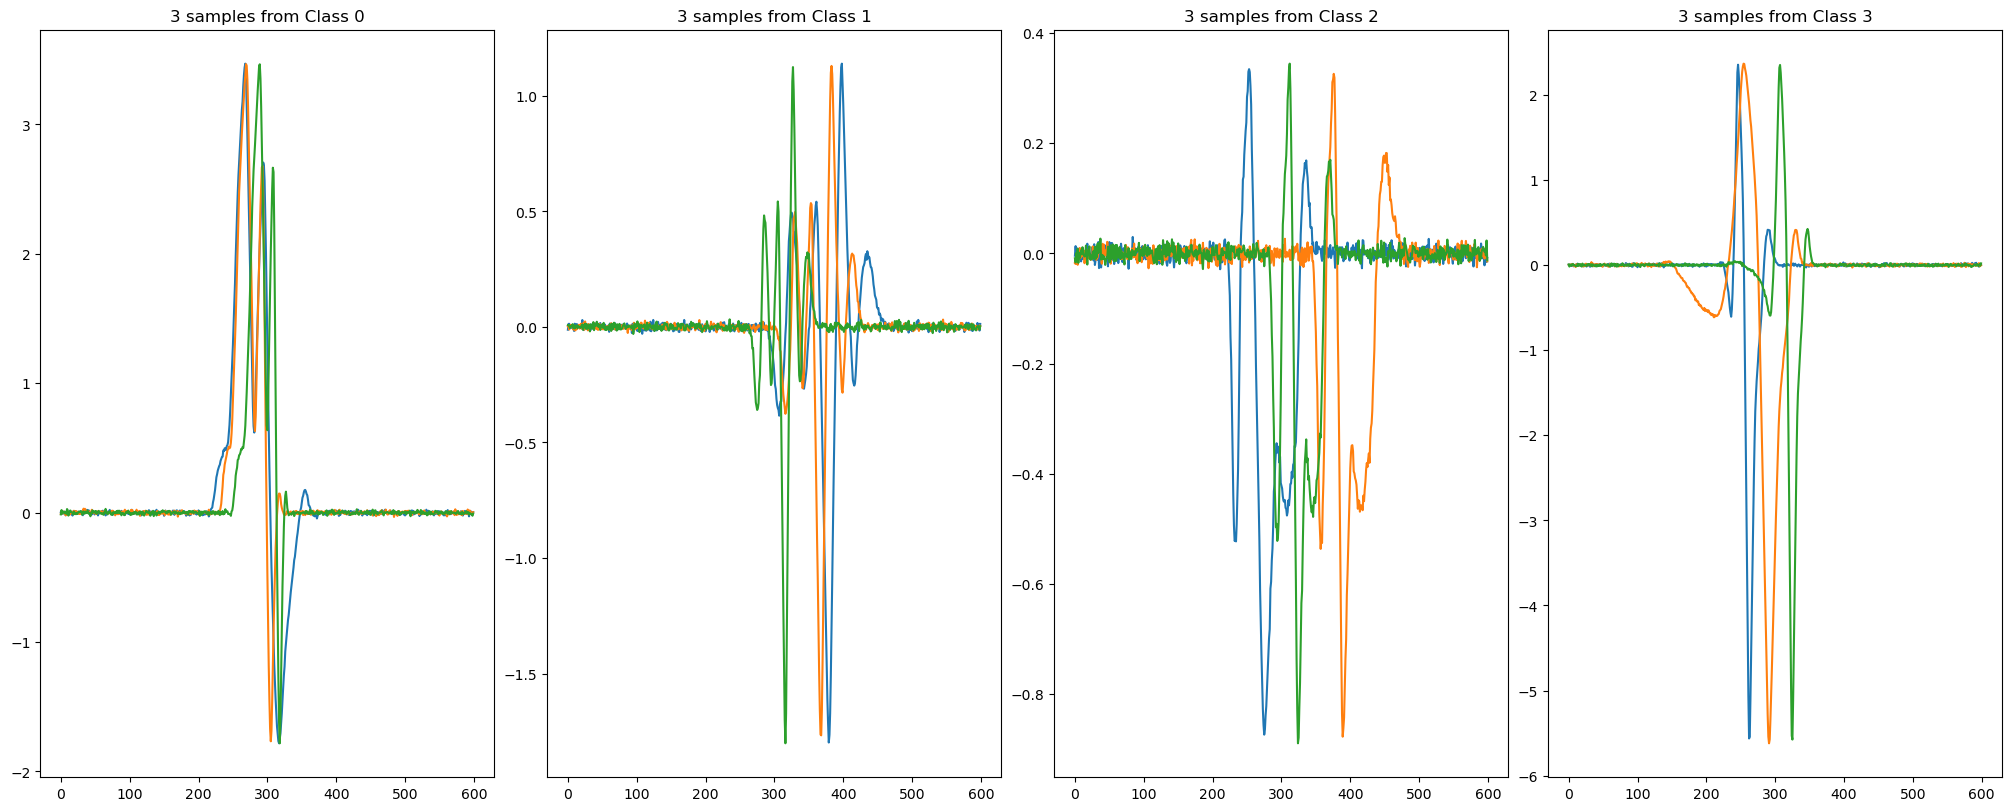

In [8]:
dataset = synthetic_dataset_builder(num_classes= 4,num_samples_per_class = 50, noise_level = 0.01, create_template = True)
print_samples(dataset, 3)
train_data, test_data = select_samples(dataset,2)

for method in [dtw,d_T]:
    accuracy = classify(train_data, test_data, method)
    print(f'{method.__name__} accuracy: {accuracy}')

# Classification of datasets from timeseriesclassification.com examples

In this section we run the same classification algorithm as before but for real-world datasets from the timer series classification repository (TSC). 
1) The first cell is an auxiliary function to get the datasets from TSC in the correct format.
2) The second cell is to create a dropdown menu so the user can choose which dataset and divergence to use.
3) The third cell loads train and test splits, runs 1NN with the chosen divergence, and reports classification accuracy.

In [11]:
def load_from_aeon(dataset):
    '''
    Loads and zero-means datasets from timeseriesclassification.com. Returns train and test separatedly.
    Train and test are matrices where the first column represents the label.
    
    Input:
        dataset: name of dataset as in timeseriesclassification.com
    Outputs:
        Train and test splits from selected dataset with labels in first column
    '''
    XX_train, yy_train = load_classification(dataset, split="train")
    XX_train = XX_train.reshape(XX_train.shape[0], XX_train.shape[-1])
    XX_train = XX_train.astype(np.float64)
    yy_train = yy_train.astype(np.float64)

    XX_test, yy_test = load_classification(dataset, split="test")
    XX_test = XX_test.reshape(XX_test.shape[0], XX_test.shape[-1])
    XX_test = XX_test.astype(np.float64)
    yy_test = yy_test.astype(np.float64)

    ZZ_train = np.hstack([yy_train.reshape(-1,1), XX_train])
    ZZ_test = np.hstack([yy_test.reshape(-1,1), XX_test])

    return ZZ_train, ZZ_test

Next cell only creates a dropdown menu to choose a dataset and divergence to run the 1NN classifier.

In [12]:

from ipywidgets import Dropdown
from ipywidgets import RadioButtons
from ipywidgets import Output
from IPython.display import display, clear_output

selected_dataset_name = 'BME'
selected_method = d_T

datasets_names = get_available_tsc_datasets()
dropdown1 = Dropdown(options= datasets_names,
                    value='BME',
                    description='Select a Dataset from Time Series Repository:',
                    style={'description_width': 'auto'}, 
                    layout={'width': '500px'}  # increase width as needed
                   )

# Create an Output widget to display results
out = Output()
def on_change_1(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global selected_dataset_name
        selected_dataset_name = change['new']
        with out:
            clear_output()
            #print(f"Selected option: {change['new']}")
        


dropdown2 = Dropdown(options=[('d_T',d_T),('dtw',dtw)],
                    value=d_T,
                    description='Select a divergence:',
                    style={'description_width': 'auto'}, 
                    layout={'width': '500px'}  # increase width as needed
                   )

# Create an Output widget to display results
def on_change_2(change):
    if change['type'] == 'change' and change['name'] == 'value':
        global selected_method
        selected_method = change['new']
        with out:
            clear_output()
            #print(f"Selected method: {change['new'].__name__}")
        
dropdown1.observe(on_change_1,'value')
dropdown2.observe(on_change_2,'value')
display(dropdown1,dropdown2, out)

Dropdown(description='Select a Dataset from Time Series Repository:', index=8, layout=Layout(width='500px'), o…

Dropdown(description='Select a divergence:', layout=Layout(width='500px'), options=(('d_T', <function d_T at 0…

Output()

In [13]:
train_data, test_data = load_from_aeon(selected_dataset_name)
accuracy = classify(train_data, test_data, selected_method)

print(f'Divergence: {selected_method.__name__}')
print(f'Dataset: {selected_dataset_name}')
print(f'Accuracy: {accuracy}')

Divergence: d_T
Dataset: BME
Accuracy: 98.71794871794873
